# Notebook 3: Baseline Machine Learning Models

**Goal:** Establish a baseline accuracy using traditional ML algorithms (Logistic Regression and SVM) BEFORE trying deep learning.

**Why start with traditional ML?**
- It shows us what's achievable WITHOUT deep learning
- It highlights WHY CNNs are so much better for images
- It gives us a reference point to measure the CNN's improvement
- It's good practice — always start simple and add complexity only when needed

---

## 3.1 Setup and Data Preparation

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time  # To measure training time

# scikit-learn: The standard library for traditional ML in Python
from sklearn.linear_model import LogisticRegression  # A linear classifier
from sklearn.svm import SVC                          # Support Vector Machine
from sklearn.metrics import accuracy_score, classification_report

# Our custom modules
from src.data_utils import get_cifar10_numpy, CIFAR10_CLASSES
from src.visualize import plot_confusion_matrix

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("All imports successful!")

All imports successful!


### Preparing Images for Traditional ML

Traditional ML models like Logistic Regression and SVM can only work with **1D feature vectors**, not 2D images. So we need to **flatten** each image.

```
Original image: 32 x 32 x 3 = a 3D grid of pixel values

Flattened:  [p1, p2, p3, ..., p3072] = a single list of 3072 numbers
```

**The problem:** By flattening, we LOSE all spatial information. The model has no idea which pixels are neighbors. A cat facing left and a cat facing right look completely different as flat vectors — even though they're both cats!

This is exactly why CNNs exist: they preserve spatial structure.

In [2]:
# Load CIFAR-10 as flattened numpy arrays
# get_cifar10_numpy() does the following:
#   1. Loads the raw CIFAR-10 data
#   2. Reshapes each (32, 32, 3) image into a (3072,) vector
#   3. Scales pixel values from [0, 255] to [0.0, 1.0]

# We use a subset_size of 10000 for training because SVM is VERY slow on 50K samples
# (SVM training time is roughly O(n^2) to O(n^3) where n = number of samples)
X_train, y_train, X_test, y_test = get_cifar10_numpy(
    data_dir='../data', 
    subset_size=10000  # Use 10K training samples (full 50K would take hours for SVM)
)

print("Data shapes:")
print(f"  X_train: {X_train.shape}  (10,000 images, each flattened to 3072 values)")
print(f"  y_train: {y_train.shape}  (10,000 labels, integers 0-9)")
print(f"  X_test:  {X_test.shape}  (10,000 test images)")
print(f"  y_test:  {y_test.shape}  (10,000 test labels)")
print(f"\n  Pixel value range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"  Data type: {X_train.dtype}")

Data shapes:
  X_train: (10000, 3072)  (10,000 images, each flattened to 3072 values)
  y_train: (10000,)  (10,000 labels, integers 0-9)
  X_test:  (10000, 3072)  (10,000 test images)
  y_test:  (10000,)  (10,000 test labels)

  Pixel value range: [0.0, 1.0]
  Data type: float32


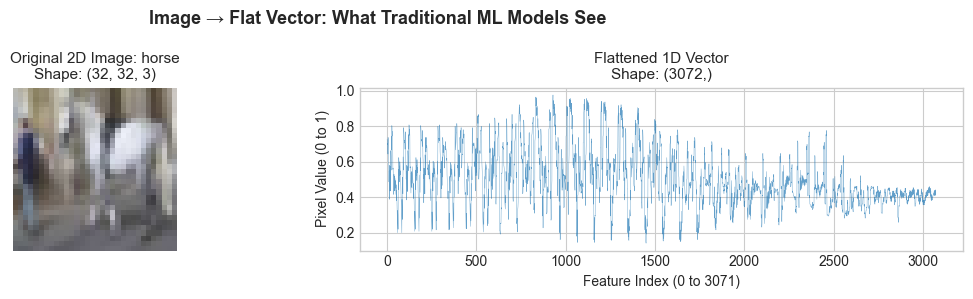

The model sees the RIGHT plot — just a stream of 3072 numbers.
All spatial relationships between pixels are LOST!
Feature 0 is the top-left pixel's red value.
Feature 1 is the next pixel's red value... and so on.


In [3]:
# Let's visualize what flattening does to an image
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Show the image in its original 2D form
# X_train[0] is a flat vector of 3072 values. We reshape it back to (32, 32, 3)
sample_img = X_train[0].reshape(32, 32, 3)
axes[0].imshow(sample_img)
axes[0].set_title(f'Original 2D Image: {CIFAR10_CLASSES[y_train[0]]}\nShape: (32, 32, 3)', fontsize=11)
axes[0].axis('off')

# Show the flattened 1D vector
axes[1].plot(X_train[0], linewidth=0.3, alpha=0.7)
axes[1].set_title(f'Flattened 1D Vector\nShape: (3072,)', fontsize=11)
axes[1].set_xlabel('Feature Index (0 to 3071)')
axes[1].set_ylabel('Pixel Value (0 to 1)')

plt.suptitle('Image → Flat Vector: What Traditional ML Models See',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("The model sees the RIGHT plot — just a stream of 3072 numbers.")
print("All spatial relationships between pixels are LOST!")
print("Feature 0 is the top-left pixel's red value.")
print("Feature 1 is the next pixel's red value... and so on.")

## 3.2 Model 1: Logistic Regression

**What is Logistic Regression?**
Despite the name, it's a **classification** algorithm (not regression).

How it works:
1. For each class, it learns a set of weights (one weight per pixel feature)
2. For a new image, it computes: `score_class = w1*pixel1 + w2*pixel2 + ... + w3072*pixel3072 + bias`
3. The class with the highest score is the prediction

It's a **linear** model — it can only draw straight-line boundaries between classes. This is a severe limitation for images where the distinction between classes is highly non-linear.

**Expected accuracy:** ~40% (random guessing would be 10% for 10 classes)

In [4]:
# Train a Logistic Regression model
print("Training Logistic Regression...")
print("(This should take about 30-60 seconds)\n")

start_time = time.time()

# LogisticRegression parameters:
# - max_iter=1000: Maximum number of optimization iterations
#   (default 100 is often not enough to converge)
# - solver='lbfgs': An efficient optimization algorithm for this problem
#   LBFGS = Limited-memory Broyden-Fletcher-Goldfarb-Shanno (a quasi-Newton method)
# - multi_class='multinomial': Use softmax for multi-class (not one-vs-rest)
#   This models all 10 classes jointly, which is more principled
# - C=1.0: Regularization strength (inverse). Lower C = more regularization.
#   Regularization prevents the model from fitting noise in the training data.

lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    C=1.0,
    n_jobs=-1  # Use all CPU cores for faster computation
)

# .fit() is where the actual learning happens
# The model finds the optimal weights by minimizing the cross-entropy loss
lr_model.fit(X_train, y_train)

lr_train_time = time.time() - start_time
print(f"Training completed in {lr_train_time:.1f} seconds")

# Make predictions on the test set
# .predict() applies the learned weights to each test image
lr_predictions = lr_model.predict(X_test)

# Calculate accuracy: (number correct) / (total images) * 100
lr_accuracy = accuracy_score(y_test, lr_predictions) * 100
print(f"\nLogistic Regression Test Accuracy: {lr_accuracy:.2f}%")
print(f"(Random guessing would give 10.0%)")

Training Logistic Regression...
(This should take about 30-60 seconds)



c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training completed in 96.1 seconds

Logistic Regression Test Accuracy: 33.46%
(Random guessing would give 10.0%)


In [5]:
# Detailed classification report: precision, recall, F1-score for each class
#
# Precision: Of all images predicted as class X, how many were actually class X?
#   Example: If we predicted 100 images as 'cat', and 70 were actually cats → precision = 70%
#
# Recall: Of all actual class X images, how many did we correctly predict?
#   Example: If there are 1000 cat images, and we found 500 → recall = 50%
#
# F1-Score: Harmonic mean of precision and recall. A balanced measure.
#   F1 = 2 * (precision * recall) / (precision + recall)

print("\nDetailed Classification Report (Logistic Regression):")
print("=" * 60)
print(classification_report(y_test, lr_predictions, target_names=CIFAR10_CLASSES))


Detailed Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    airplane       0.40      0.38      0.39      1000
  automobile       0.40      0.37      0.38      1000
        bird       0.24      0.25      0.24      1000
         cat       0.21      0.21      0.21      1000
        deer       0.29      0.27      0.28      1000
         dog       0.28      0.28      0.28      1000
        frog       0.36      0.37      0.36      1000
       horse       0.37      0.35      0.36      1000
        ship       0.42      0.49      0.45      1000
       truck       0.37      0.38      0.38      1000

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000



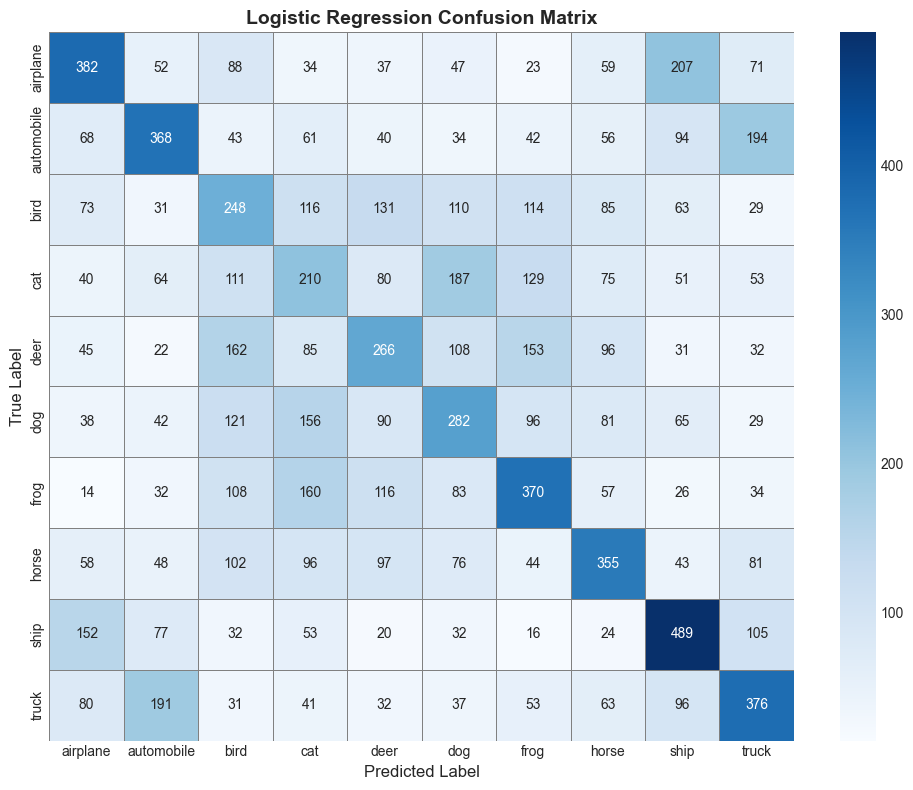


Reading the confusion matrix:
- Diagonal (top-left to bottom-right) = CORRECT predictions
- Off-diagonal = ERRORS (row = true class, column = predicted class)
- Look for large off-diagonal numbers to see common confusions

Typical confusions: cat↔dog, automobile↔truck (visually similar pairs)


In [6]:
# Confusion Matrix: shows exactly which classes get confused with each other
fig = plot_confusion_matrix(
    y_test, lr_predictions, CIFAR10_CLASSES,
    title='Logistic Regression Confusion Matrix'
)
plt.show()

print("\nReading the confusion matrix:")
print("- Diagonal (top-left to bottom-right) = CORRECT predictions")
print("- Off-diagonal = ERRORS (row = true class, column = predicted class)")
print("- Look for large off-diagonal numbers to see common confusions")
print("\nTypical confusions: cat↔dog, automobile↔truck (visually similar pairs)")

## 3.3 Model 2: Support Vector Machine (SVM)

**What is an SVM?**
An SVM finds the best **boundary** (hyperplane) that separates different classes.

Key concepts:
- **Support vectors:** The data points closest to the decision boundary. These are the "hardest" examples and define where the boundary is.
- **Margin:** The distance between the boundary and the nearest support vectors. SVM maximizes this margin.
- **Kernel trick:** Using an RBF (Radial Basis Function) kernel, the SVM can learn **non-linear** boundaries by implicitly mapping data to a higher-dimensional space.

**Expected accuracy:** ~45-55% (better than Logistic Regression because the kernel allows non-linear boundaries)

**Note:** SVM training time scales poorly with dataset size. On 10K samples, it takes a few minutes. On 50K, it would take hours.

In [7]:
# Train an SVM with RBF kernel
print("Training SVM with RBF kernel...")
print("(This may take 2-5 minutes on 10K training samples)\n")

start_time = time.time()

# SVC (Support Vector Classifier) parameters:
# - kernel='rbf': Radial Basis Function kernel.
#   RBF measures similarity between points. Points close together in feature space
#   get high similarity. This allows non-linear decision boundaries.
#   Mathematically: K(x, y) = exp(-gamma * ||x - y||^2)
#
# - C=10.0: Regularization parameter (higher = less regularization).
#   C controls the trade-off between:
#   - A wider margin (more generalization, some misclassifications allowed)
#   - A narrower margin (fewer training errors, risk of overfitting)
#
# - gamma='scale': Kernel coefficient. 'scale' means gamma = 1/(n_features * X.var())
#   This is a reasonable default that adapts to the data.

svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

svm_train_time = time.time() - start_time
print(f"Training completed in {svm_train_time:.1f} seconds")

# Predict on test set
svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions) * 100
print(f"\nSVM Test Accuracy: {svm_accuracy:.2f}%")
print(f"Improvement over Logistic Regression: +{svm_accuracy - lr_accuracy:.1f}%")

Training SVM with RBF kernel...
(This may take 2-5 minutes on 10K training samples)

Training completed in 218.6 seconds

SVM Test Accuracy: 47.92%
Improvement over Logistic Regression: +14.5%


In [8]:
# SVM Classification Report
print("\nDetailed Classification Report (SVM):")
print("=" * 60)
print(classification_report(y_test, svm_predictions, target_names=CIFAR10_CLASSES))


Detailed Classification Report (SVM):
              precision    recall  f1-score   support

    airplane       0.55      0.56      0.55      1000
  automobile       0.56      0.59      0.58      1000
        bird       0.36      0.41      0.38      1000
         cat       0.30      0.32      0.31      1000
        deer       0.44      0.41      0.43      1000
         dog       0.40      0.38      0.39      1000
        frog       0.54      0.51      0.52      1000
       horse       0.55      0.47      0.51      1000
        ship       0.61      0.62      0.61      1000
       truck       0.52      0.52      0.52      1000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.48     10000
weighted avg       0.48      0.48      0.48     10000



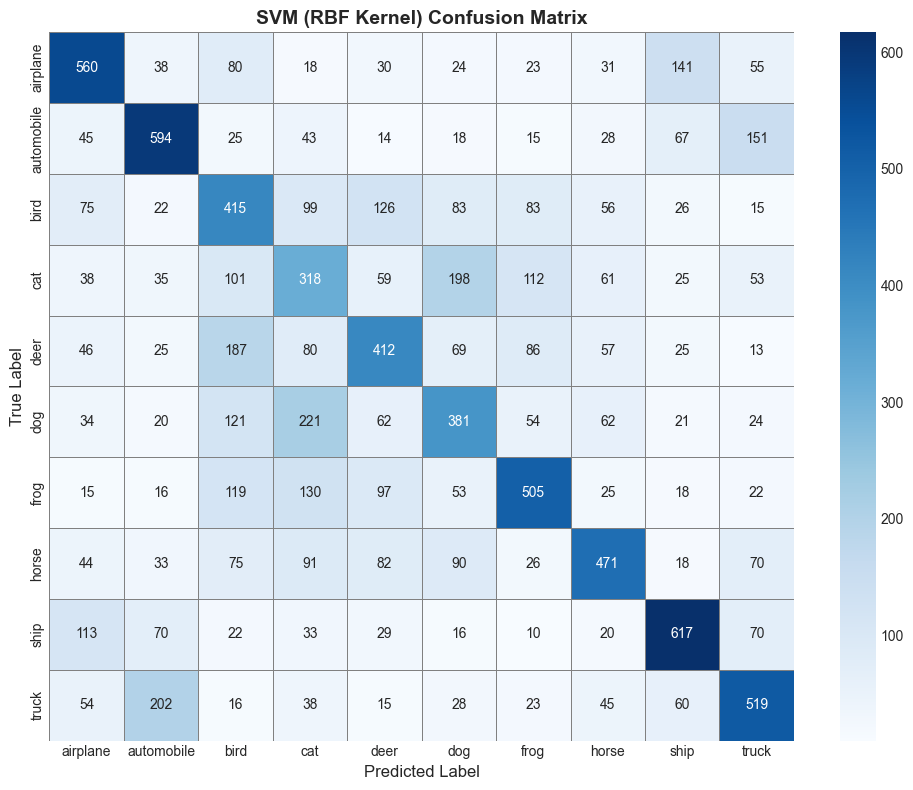

In [9]:
# SVM Confusion Matrix
fig = plot_confusion_matrix(
    y_test, svm_predictions, CIFAR10_CLASSES,
    title='SVM (RBF Kernel) Confusion Matrix'
)
plt.show()

## 3.4 Baseline Results Summary

Let's compare our two traditional ML models.

In [11]:
# Summary comparison
print("\n" + "=" * 60)
print("BASELINE RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>10} {'Train Time':>12}")
print("-" * 47)
print(f"{'Random Guessing':<25} {'10.00%':>10} {'N/A':>12}")
print(f"{'Logistic Regression':<25} {f'{lr_accuracy:.2f}%':>10} {f'{lr_train_time:.1f}s':>12}")
print(f"{'SVM (RBF Kernel)':<25} {f'{svm_accuracy:.2f}%':>10} {f'{svm_train_time:.1f}s':>12}")
print(f"{'CNN (coming next!)':<25} {'~85-90%':>10} {'~30 min':>12}")
print("=" * 60)

# Save results for comparison in Notebook 5
import json

baseline_results = {
    'logistic_regression': {
        'accuracy': lr_accuracy,
        'train_time': lr_train_time,
        'predictions': lr_predictions.tolist(),
        'true_labels': y_test.tolist()
    },
    'svm': {
        'accuracy': svm_accuracy,
        'train_time': svm_train_time,
        'predictions': svm_predictions.tolist(),
        'true_labels': y_test.tolist()
    }
}

with open('../saved_models/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f)
    
print("\nBaseline results saved to saved_models/baseline_results.json")


BASELINE RESULTS SUMMARY
Model                       Accuracy   Train Time
-----------------------------------------------
Random Guessing               10.00%          N/A
Logistic Regression           33.46%        96.1s
SVM (RBF Kernel)              47.92%       218.6s
CNN (coming next!)           ~85-90%      ~30 min

Baseline results saved to saved_models/baseline_results.json


## 3.5 Why Do Traditional ML Models Struggle?

### The Core Problem: No Spatial Awareness

When we flatten a 32x32 image into a 3072-dimensional vector:
- **Pixel position is lost:** The model doesn't know that pixel (0,0) is the top-left corner
- **Neighbor relationships are destroyed:** Adjacent pixels in the image are not adjacent in the flat vector
- **Translation sensitivity:** A cat at the center vs. a cat at the edge creates completely different feature vectors, even though both are cats

### What Each Model Can Do:

**Logistic Regression:**
- Can only learn linear decision boundaries
- Essentially learns: "if the average color in certain pixel positions is high, predict this class"
- Cannot capture ANY spatial patterns (edges, textures, shapes)

**SVM (RBF kernel):**
- Can learn non-linear boundaries (better!)
- Measures overall similarity between images
- Still treats each pixel independently — no spatial understanding
- Scales poorly to large datasets (slow training)

### What CNNs Do Differently:
- **Preserve spatial structure:** Work directly with 2D images
- **Learn local patterns:** Detect edges, textures, and shapes via convolution
- **Build hierarchical features:** Simple patterns → complex patterns → objects
- **Weight sharing:** Same filter applied everywhere → far fewer parameters
- **Translation invariance:** Can recognize a cat regardless of its position

### Next: Let's see the CNN in action!